# Geographic and Crash Severity Analysis

## Beyond the Crash Count

This notebook investigates how reported crash frequency and serious
crash outcomes vary geographically across North Carolina.

The analysis focuses on the five complete calendar years from
2021 through 2025.

### Primary questions

1. Where are the largest numbers of reported crashes recorded?
2. Where are serious crash outcomes relatively more common among
   recorded crashes?
3. Do areas with high crash frequency necessarily have high crash
   severity?
4. How do crash outcomes differ between records classified as rural
   and municipal/city?

### Primary severity metric

A **serious crash** is defined as an NCDOT severity `K` (fatal) or
`A` (serious/disabling injury) crash.

The **Serious Outcome Rate** is:

> K+A crashes per 1,000 recorded crashes with known severity.

Records coded `U` (unknown severity) are retained in the source data
but excluded from the denominator.

### Interpretation

This metric describes severity among recorded crashes. It should not
be interpreted as the probability of crashing or as a complete measure
of roadway danger because the dataset does not currently include an
exposure measure such as vehicle miles traveled.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise RuntimeError(
        "Could not locate the project root containing the src/ directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import load_crash_data
from src.metrics import (
    known_severity_crash_count,
    serious_crash_count,
    serious_rate_per_1000,
)

In [2]:
df = load_crash_data()

statewide_serious_rate = serious_rate_per_1000(df)

print(f"Crash records: {len(df):,}")
print(
    f"Analysis period: "
    f"{df['Year'].min()}–{df['Year'].max()}"
)
print(f"Counties represented: {df['County'].nunique()}")
print(
    f"NC Serious Outcome Rate: "
    f"{statewide_serious_rate:.2f} per 1,000 known-severity crashes"
)

Crash records: 1,535,119
Analysis period: 2021–2025
Counties represented: 100
NC Serious Outcome Rate: 19.88 per 1,000 known-severity crashes


In [3]:
county_values = (
    df["County"]
    .value_counts(dropna=False)
    .rename_axis("County")
    .reset_index(name="crash_count")
)

county_values

,County,crash_count
0,Mecklenburg,201315
1,Wake,175360
2,Guilford,74993
3,Forsyth,66410
4,Durham,55149
...,...,...
95,Alleghany,969
96,Gates,919
97,Graham,838
98,Tyrrell,515


In [4]:
print(f"Unique County values: {df['County'].nunique(dropna=False)}")
print(f"Missing County values: {df['County'].isna().sum():,}")

Unique County values: 100
Missing County values: 0


In [5]:
sorted(
    df["County"]
    .dropna()
    .astype(str)
    .unique()
)

['Alamance',
 'Alexander',
 'Alleghany',
 'Anson',
 'Ashe',
 'Avery',
 'Beaufort',
 'Bertie',
 'Bladen',
 'Brunswick',
 'Buncombe',
 'Burke',
 'Cabarrus',
 'Caldwell',
 'Camden',
 'Carteret',
 'Caswell',
 'Catawba',
 'Chatham',
 'Cherokee',
 'Chowan',
 'Clay',
 'Cleveland',
 'Columbus',
 'Craven',
 'Cumberland',
 'Currituck',
 'Dare',
 'Davidson',
 'Davie',
 'Duplin',
 'Durham',
 'Edgecombe',
 'Forsyth',
 'Franklin',
 'Gaston',
 'Gates',
 'Graham',
 'Granville',
 'Greene',
 'Guilford',
 'Halifax',
 'Harnett',
 'Haywood',
 'Henderson',
 'Hertford',
 'Hoke',
 'Hyde',
 'Iredell',
 'Jackson',
 'Johnston',
 'Jones',
 'Lee',
 'Lenoir',
 'Lincoln',
 'Macon',
 'Madison',
 'Martin',
 'Mcdowell',
 'Mecklenburg',
 'Mitchell',
 'Montgomery',
 'Moore',
 'Nash',
 'New Hanover',
 'Northampton',
 'Onslow',
 'Orange',
 'Pamlico',
 'Pasquotank',
 'Pender',
 'Perquimans',
 'Person',
 'Pitt',
 'Polk',
 'Randolph',
 'Richmond',
 'Robeson',
 'Rockingham',
 'Rowan',
 'Rutherford',
 'Sampson',
 'Scotland',
 '

In [6]:
area_summary = (
    df["area_type"]
    .value_counts(dropna=False)
    .rename_axis("area_type")
    .reset_index(name="crash_count")
)

area_summary["percent"] = (
    area_summary["crash_count"] / len(df) * 100
)

area_summary

,area_type,crash_count,percent
0,Municipal/City,994277,64.768725
1,Rural,537865,35.037349
2,Unknown,2977,0.193926


In [3]:
from src.geography import build_county_summary

In [4]:
county_summary = build_county_summary(df)

county_summary.head(10)

,County,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000,severity_multiplier
0,Mecklenburg,201315,191119,1509,7.895604,0.397093
1,Wake,175360,169781,2252,13.264146,0.667093
2,Guilford,74993,72975,846,11.593011,0.583046
3,Forsyth,66410,63250,1057,16.711462,0.840468
4,Durham,55149,52598,605,11.502338,0.578486
5,Cumberland,48084,46237,1192,25.780219,1.296562
6,Buncombe,40733,39357,456,11.586249,0.582706
7,Gaston,38668,37420,553,14.778193,0.743238
8,New Hanover,32103,30877,364,11.788710,0.592889
9,Johnston,31527,30384,735,24.190363,1.216604


In [5]:
county_summary.sort_values(
    "serious_rate_per_1000",
    ascending=False
).head(15)

,County,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000,severity_multiplier
97,Graham,838,816,119,145.833333,7.334383
93,Swain,1048,1013,70,69.101678,3.475325
82,Warren,2108,1965,126,64.122137,3.224889
96,Gates,919,900,53,58.888889,2.961694
79,Currituck,2347,2320,126,54.310345,2.731426
78,Northampton,2423,2301,123,53.455020,2.688409
72,Montgomery,2920,2828,151,53.394625,2.685371
65,Scotland,4390,4238,179,42.236904,2.124217
35,Sampson,9889,9399,395,42.025747,2.113597
37,Columbus,9686,9182,381,41.494228,2.086866


In [6]:
county_summary.sort_values(
    "serious_crash_count",
    ascending=False
).head(15)

,County,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000,severity_multiplier
1,Wake,175360,169781,2252,13.264146,0.667093
0,Mecklenburg,201315,191119,1509,7.895604,0.397093
5,Cumberland,48084,46237,1192,25.780219,1.296562
3,Forsyth,66410,63250,1057,16.711462,0.840468
16,Robeson,24426,23132,919,39.728515,1.998063
2,Guilford,74993,72975,846,11.593011,0.583046
9,Johnston,31527,30384,735,24.190363,1.216604
18,Davidson,21306,20521,666,32.454559,1.632234
13,Iredell,27741,26882,618,22.989361,1.156202
15,Alamance,24662,23840,612,25.671141,1.291077


In [7]:
county_summary[
    [
        "crash_count",
        "known_severity_count",
        "serious_crash_count",
        "serious_rate_per_1000",
        "severity_multiplier",
    ]
].describe()

,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000,severity_multiplier
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,15351.190000,14786.620000,294.010000,30.556830,1.536792
std,28472.818457,27290.896999,326.064271,15.938377,0.801587
min,334.000000,327.000000,6.000000,7.895604,0.397093
25%,2803.250000,2684.250000,112.500000,22.968875,1.155172
50%,7506.000000,7211.500000,204.500000,29.096348,1.463340
75%,16001.250000,15510.500000,368.250000,34.360279,1.728079
max,201315.000000,191119.000000,2252.000000,145.833333,7.334383


In [8]:
county_summary.sort_values(
    "known_severity_count"
).head(15)

,County,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000,severity_multiplier
99,Hyde,334,327,6,18.348624,0.922806
98,Tyrrell,515,509,13,25.540275,1.284495
97,Graham,838,816,119,145.833333,7.334383
96,Gates,919,900,53,58.888889,2.961694
95,Alleghany,969,939,32,34.078807,1.713923
94,Camden,1009,992,29,29.233871,1.470257
93,Swain,1048,1013,70,69.101678,3.475325
92,Chowan,1189,1160,30,25.862069,1.300679
91,Pamlico,1207,1183,37,31.276416,1.572982
90,Yancey,1325,1317,51,38.724374,1.947562


## Investigating County-Level Outliers

The initial county comparison reveals substantial variation in Serious
Outcome Rates.

Before interpreting extreme county values, particularly Graham County,
we examine their underlying crash counts, severity composition, and
temporal distribution.

This step helps distinguish persistent patterns from results that may
be driven by a particular year, severity category, or small number of
records.

In [9]:
graham = df[df["County"] == "Graham"].copy()

pd.crosstab(
    graham["Year"],
    graham["CrshSeverity"],
    margins=True
)

CrshSeverity,A,B,C,K,O,U,All
Year,,,,,,,
2021,24,25,20,4,98,2,173
2022,27,31,21,3,84,2,168
2023,9,22,17,5,95,1,149
2024,20,39,17,1,100,9,186
2025,21,38,12,5,78,8,162
All,101,155,87,18,455,22,838


In [10]:
graham_yearly = []

for year, year_df in graham.groupby("Year"):
    graham_yearly.append({
        "Year": year,
        "crash_count": len(year_df),
        "known_severity_count": known_severity_crash_count(year_df),
        "serious_crash_count": serious_crash_count(year_df),
        "serious_rate_per_1000": serious_rate_per_1000(year_df),
    })

graham_yearly = pd.DataFrame(graham_yearly)

graham_yearly

,Year,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000
0,2021,173,171,28,163.742690
1,2022,168,166,30,180.722892
2,2023,149,148,14,94.594595
3,2024,186,177,21,118.644068
4,2025,162,154,26,168.831169


In [11]:
graham["area_type"].value_counts(dropna=False)

area_type
Rural             719
Municipal/City    119
Name: count, dtype: int64

In [12]:
county_summary[
    ["crash_count", "serious_rate_per_1000"]
].corr()

,crash_count,serious_rate_per_1000
crash_count,1.000000,-0.365136
serious_rate_per_1000,-0.365136,1.000000


In [6]:
%pip install scipy

  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl (22.4 MB)

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
pearson_corr = county_summary[
    "crash_count"
].corr(
    county_summary["serious_rate_per_1000"],
    method="pearson"
)

spearman_corr = county_summary[
    "crash_count"
].corr(
    county_summary["serious_rate_per_1000"],
    method="spearman"
)

print(
    f"Pearson correlation: {pearson_corr:.3f}"
)

print(
    f"Spearman correlation: {spearman_corr:.3f}"
)

Pearson correlation: -0.365
Spearman correlation: -0.656


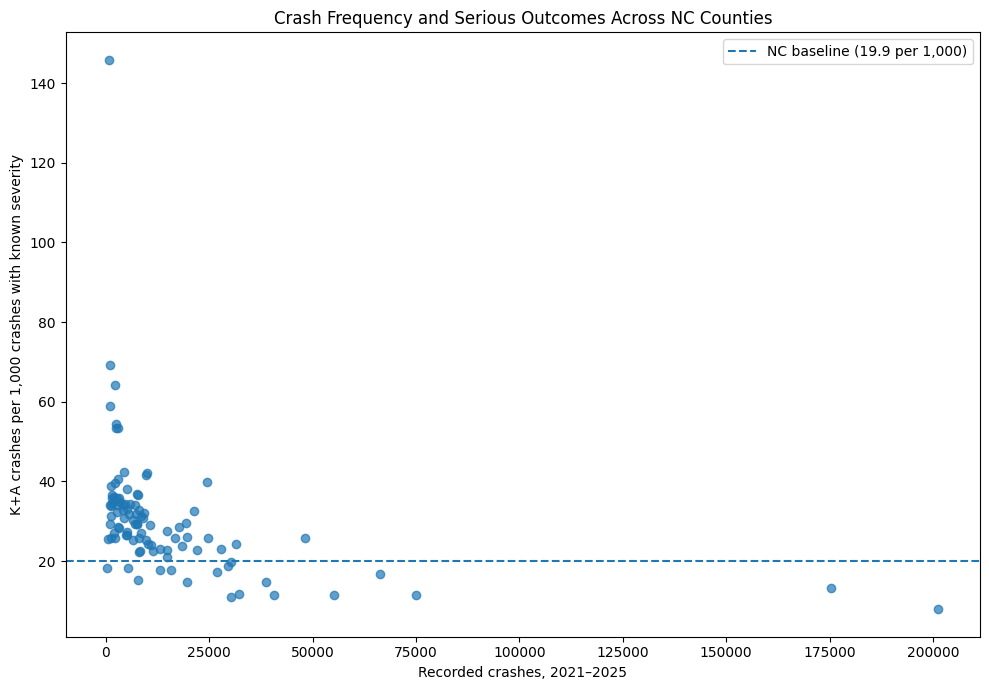

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    county_summary["crash_count"],
    county_summary["serious_rate_per_1000"],
    alpha=0.7
)

ax.axhline(
    statewide_serious_rate,
    linestyle="--",
    label=f"NC baseline ({statewide_serious_rate:.1f} per 1,000)"
)

ax.set_xlabel("Recorded crashes, 2021–2025")
ax.set_ylabel("K+A crashes per 1,000 crashes with known severity")
ax.set_title(
    "Crash Frequency and Serious Outcomes Across NC Counties"
)

ax.legend()

plt.tight_layout()
plt.show()

In [15]:
area_records = []

for area_type, area_df in df.groupby("area_type"):
    area_records.append({
        "area_type": area_type,
        "crash_count": len(area_df),
        "known_severity_count": known_severity_crash_count(area_df),
        "serious_crash_count": serious_crash_count(area_df),
        "serious_rate_per_1000": serious_rate_per_1000(area_df),
    })

area_severity_summary = pd.DataFrame(area_records)

area_severity_summary

,area_type,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000
0,Municipal/City,994277,955044,11296,11.827727
1,Rural,537865,520762,18045,34.651146
2,Unknown,2977,2856,60,21.008403
